In [161]:
# ...existing code...
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

# Velocity feature: count of same Amount within the last 1 hour (3600s), including current txn
df["_row_id"] = np.arange(len(df), dtype=np.int64)

tmp = df[["_row_id", "Time", "Amount"]].sort_values("Time").reset_index(drop=True)
tmp["Transaction_Count_1H"] = 0

for amt, g in tmp.groupby("Amount", sort=False):
    t = g["Time"].to_numpy()
    left = np.searchsorted(t, t - 3600, side="left")
    right = np.arange(len(t)) + 1
    counts = right - left
    tmp.loc[g.index, "Transaction_Count_1H"] = counts

df = df.merge(tmp[["_row_id", "Transaction_Count_1H"]], on="_row_id", how="left")
df.drop(columns=["_row_id"], inplace=True)
df["Transaction_Count_1H"] = df["Transaction_Count_1H"].astype(np.int16)

print("Added feature: Transaction_Count_1H")
print(df[["Time", "Amount", "Transaction_Count_1H"]].head())
# ...existing code...

Added feature: Transaction_Count_1H
   Time  Amount  Transaction_Count_1H
0   0.0  149.62                     1
1   0.0    2.69                     1
2   1.0  378.66                     1
3   1.0  123.50                     1
4   2.0   69.99                     1


In [162]:
#this counts a data cleaning since we are removing redundant data 
# df2=df[df["Class"]==1]
# 
# print(df2.duplicated().sum())
# 

#df = df.drop_duplicates()

print(len(df[df["Class"] == 1]))
print(len(df[df["Class"] == 0]))

print((473/284807) * (100))

print(df.duplicated().sum())

492
284315
0.16607737871611303
0


In [163]:
df.dtypes #lazy one

Time                    float64
V1                      float64
V2                      float64
V3                      float64
V4                      float64
V5                      float64
V6                      float64
V7                      float64
V8                      float64
V9                      float64
V10                     float64
V11                     float64
V12                     float64
V13                     float64
V14                     float64
V15                     float64
V16                     float64
V17                     float64
V18                     float64
V19                     float64
V20                     float64
V21                     float64
V22                     float64
V23                     float64
V24                     float64
V25                     float64
V26                     float64
V27                     float64
V28                     float64
Amount                  float64
Class                     int64
Transact

In [164]:
print("nof of frauds are ")
print(df[df["Class"]==1].shape)
print("nof of no frauds are ")
print(df[df["Class"]==0].shape)



nof of frauds are 
(492, 32)
nof of no frauds are 
(284315, 32)


In [165]:
import math
x = df["Time"].to_list()
print(max(x))

x = [math.floor((i / 3600) % 24) for i in x]

print(max(x))

y = df["Class"].to_list()


172792.0
23


In [166]:
time_fraud = {}
for i in range(24):
    time_fraud[i] = 0

# zip is a built in function that allows us to iterate over two lists at the same time
# here we are iterating over the time and fraud lists at the same time and counting the number of frauds for each hour of the day
for time, fraud in zip(x, y):
    if fraud == 1:
        time_fraud[time] = time_fraud[time] + 1   # Changed x → time

for time, fraud in time_fraud.items():
    print(f'{time} : {fraud}')

0 : 6
1 : 10
2 : 57
3 : 17
4 : 23
5 : 11
6 : 9
7 : 23
8 : 9
9 : 16
10 : 8
11 : 53
12 : 17
13 : 17
14 : 23
15 : 26
16 : 22
17 : 29
18 : 33
19 : 19
20 : 18
21 : 16
22 : 9
23 : 21


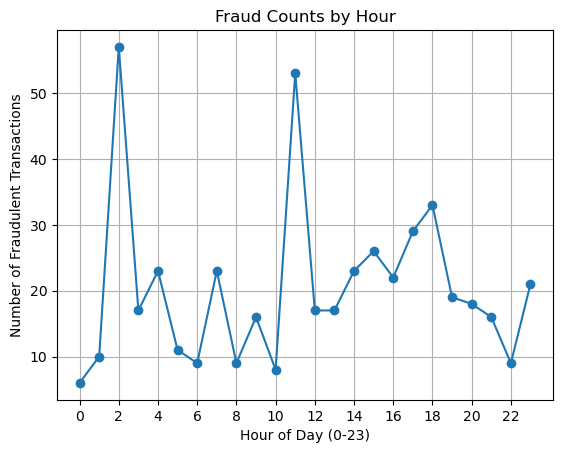

In [167]:
import matplotlib.pyplot as plt

hours = list(time_fraud.keys())
fraud_counts = list(time_fraud.values())

plt.plot(hours, fraud_counts, marker='o')  
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraudulent Transactions')
plt.title('Fraud Counts by Hour')
plt.xticks(range(0, 24, 2)) 
plt.grid(True)
plt.show()

# Drop the Time col 

In [168]:
cols=df.columns
print(cols)
for i in cols:
   print((df[i].isnull().sum()))

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Transaction_Count_1H'],
      dtype='object')
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [169]:
print(df)

            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V22       V23  \
0       0.462388  0.239599  0.098698  0.363787  ...  0.27783

#okay so i 249 fraud data points

<Axes: >

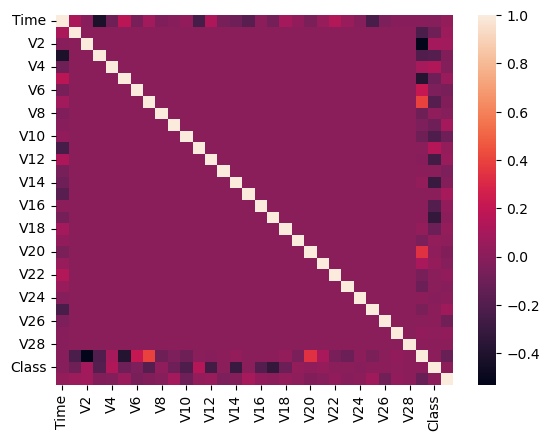

In [170]:
import seaborn as sns
cor=df.corr()
sns.heatmap(cor)

#can u guys see any useful info from this ?

In [171]:
cols=df.columns

print(cols)
tot=0
ctot=0
for i in cols[1:-2]:

     tot+=df[i].var()
for i in cols[1:-2]:
     print(i+" "+str(df[i].var()/tot))

for i in cols[1:-2]:
     ctot+=df[i].var()/tot
     print(i+" "+str(ctot))
# Explains how PCA ouptput should look like -> Higher total ratio to the lowest also before
# it's wrong didn't include the v1.. 

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Transaction_Count_1H'],
      dtype='object')
V1 6.129477810202669e-05
V2 4.356582733708534e-05
V3 3.6731104377563854e-05
V4 3.202840981198207e-05
V5 3.0437077327375077e-05
V6 2.8357941282762963e-05
V7 2.4450886532785016e-05
V8 2.2790551258827716e-05
V9 1.9283863606574438e-05
V10 1.8941981803649547e-05
V11 1.664549854056432e-05
V12 1.5951280420964766e-05
V13 1.5826140247395644e-05
V14 1.4681159735789275e-05
V15 1.338540790561615e-05
V16 1.2267283876941993e-05
V17 1.1525231142965573e-05
V18 1.1224322874629593e-05
V19 1.058720974045076e-05
V20 9.495411234634031e-06
V21 8.619885350222707e-06
V22 8.414060010433647e-06
V23 6.2301593077973044e-06
V24 5.860419830489652e-06
V25 4.341386001521831e-06
V26 3.7152886525785495e-06
V27 2.602925488469532e-06
V28

In [172]:
cols[0]

'Time'

In [173]:
# comment this out 

# import matplotlib.pyplot as plt

# clas = [float(0), float(1)]
# colors = ['red', 'blue']      

# for j in range(1, len(cols) - 2):
#     for i, k in zip(clas, colors):
#         subset = df[df['Class'] == i]
#         print(subset.shape)
#         plt.scatter(subset[cols[j]], subset[cols[j+1]], color=k, label=f"Class {i}")      

#   plt.xlabel(cols[j])
#   plt.ylabel(cols[j+1])
#   plt.legend()
#   plt.show()



#what do u guys  infer fomr the plots ?
#one things for sure we cant use clustering of any kind

we can't visually separate fraud and not fraud one beacuse it's enclosed no clear separation.

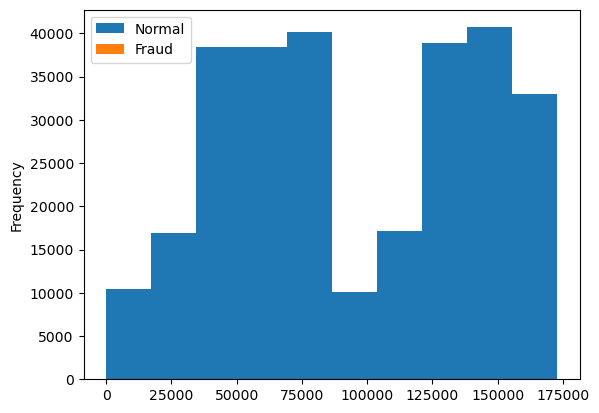

In [174]:
# Time feature is not giving us any useful information as we can see from the above plot.
import matplotlib.pyplot as plt

df.groupby('Class')['Time'].plot(kind='hist')
plt.legend(['Normal','Fraud'])
plt.show()

# Does this plot gave you any idea?? -> [Dharhas]

<Axes: xlabel='Class', ylabel='Amount'>

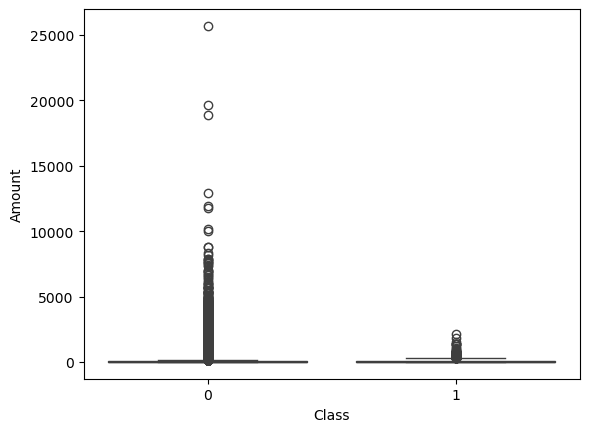

In [175]:

import seaborn as sns

sns.boxplot(x='Class', y='Amount', data=df)

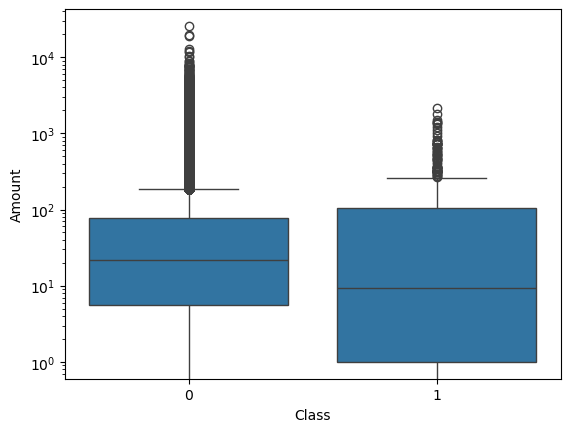

In [176]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.show()

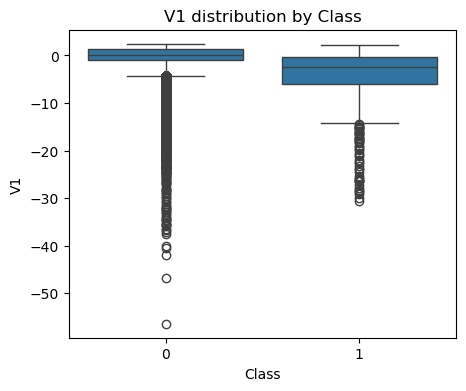

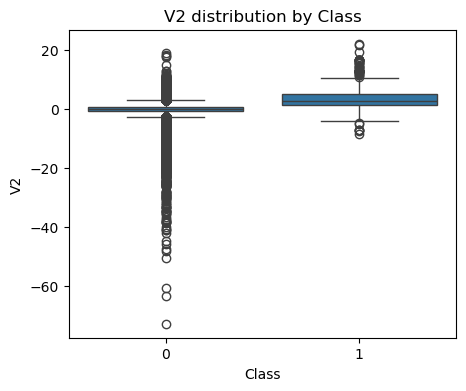

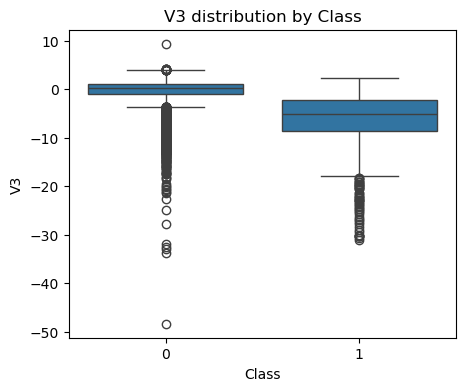

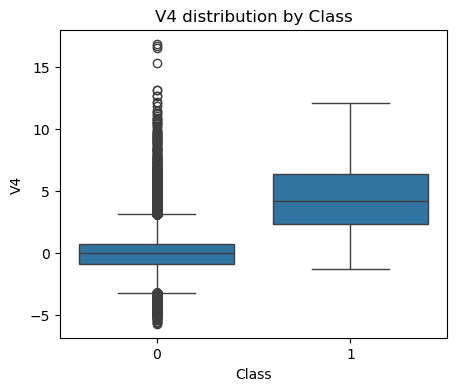

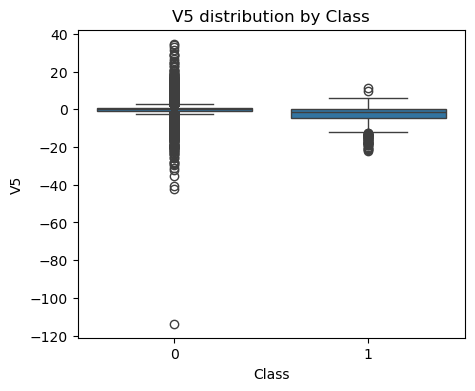

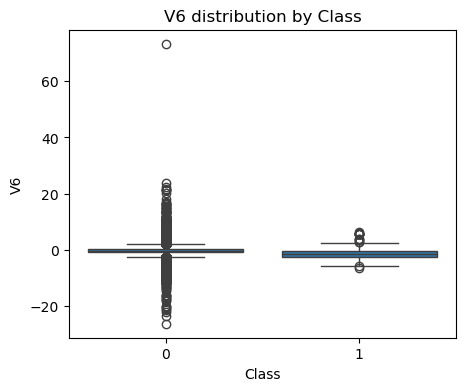

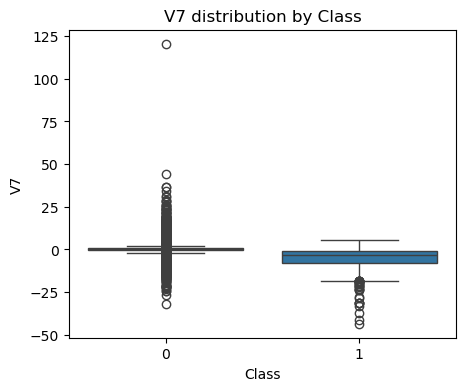

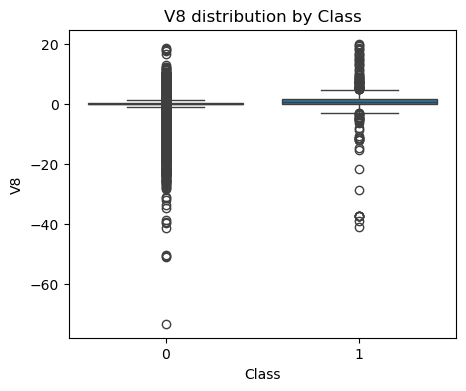

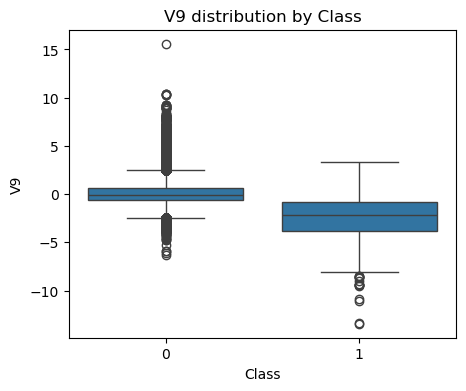

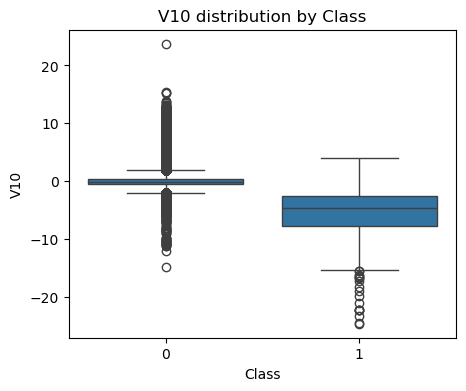

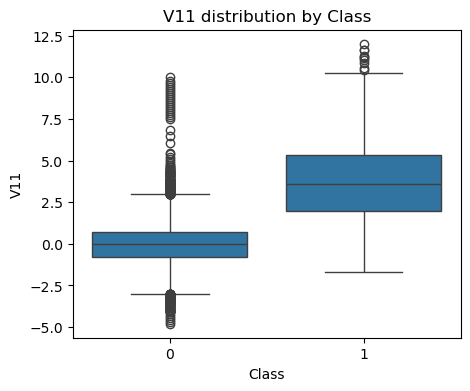

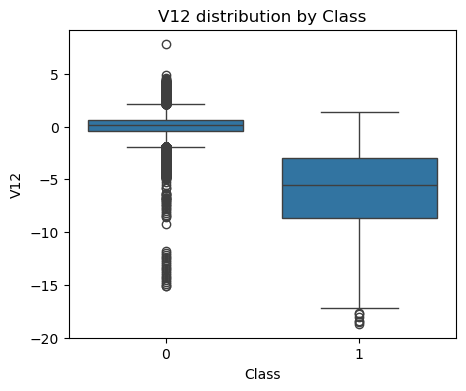

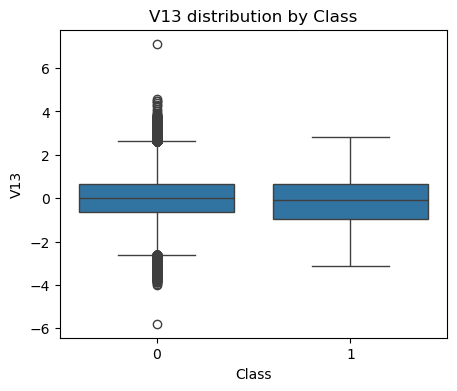

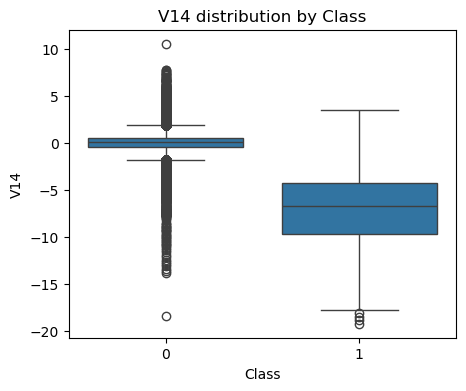

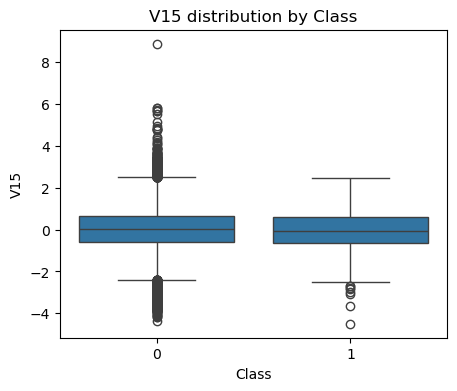

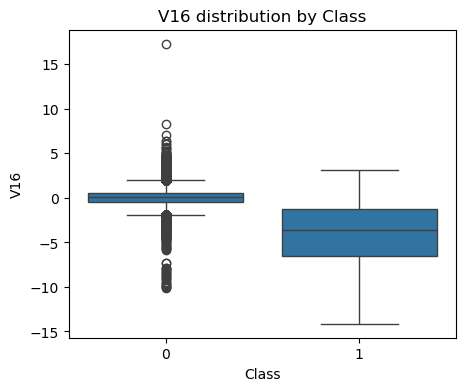

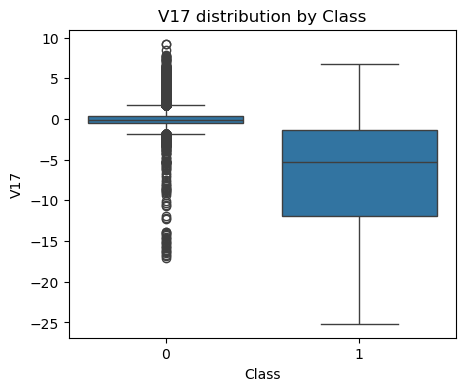

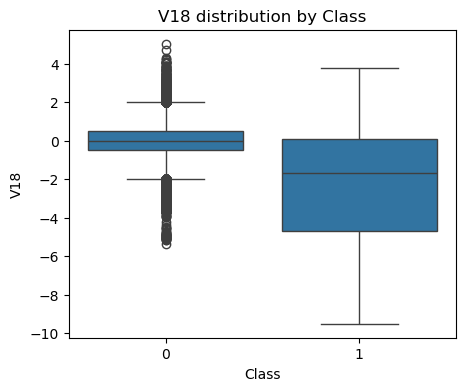

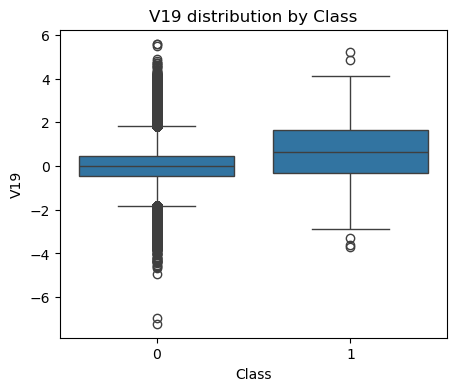

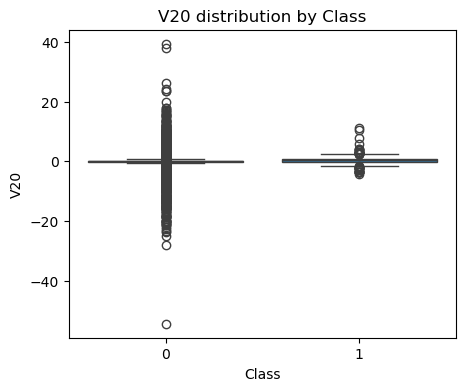

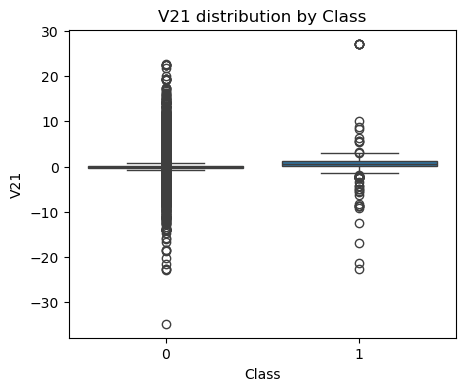

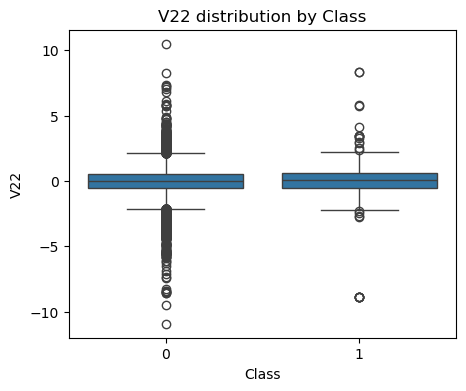

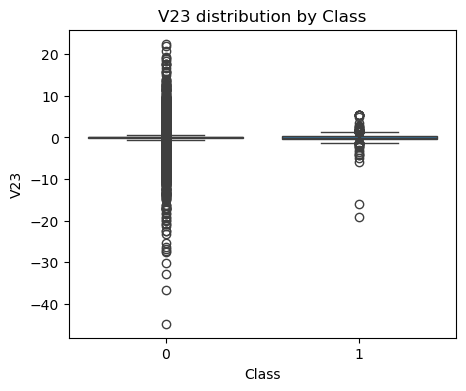

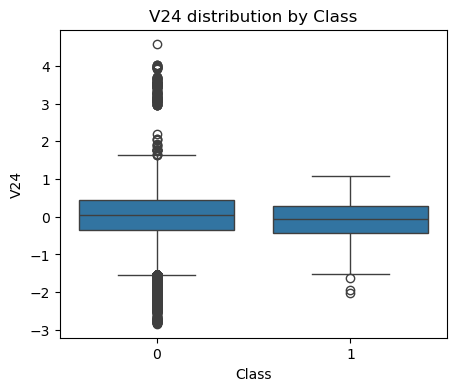

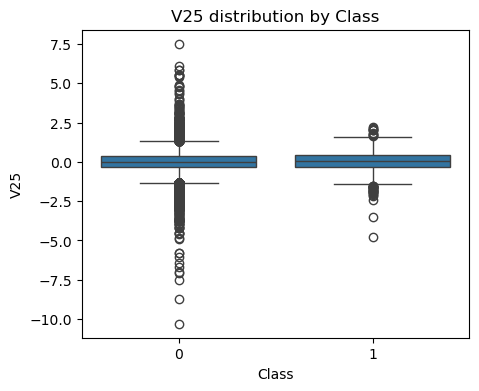

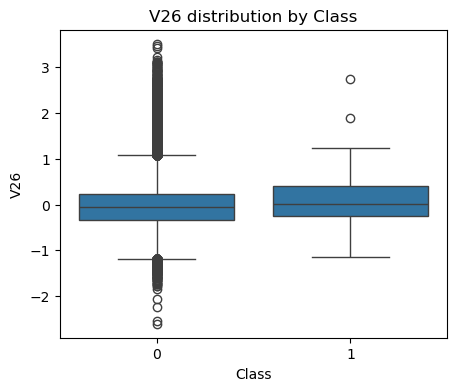

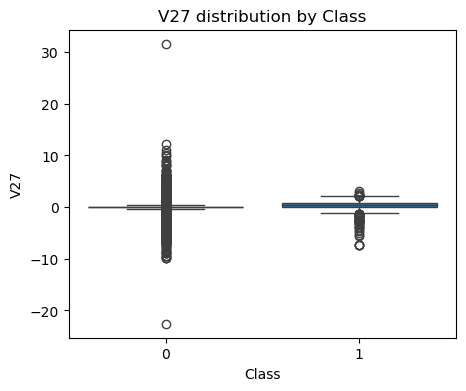

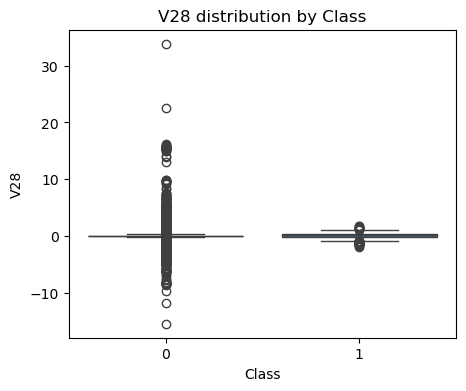

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

pcs = [f'V{i}' for i in range(1, 29)]

for pc in pcs:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='Class', y=pc, data=df)
    plt.title(f"{pc} distribution by Class")
    plt.show()

#**Again here i dont find any good inference **
**Mostly all class 1 are clustered so we use that one as plus over class 0 **
ut i wnt hink much info gain from that



**What does this  mean do fraud transaction happen ony using less amount ??**

isn't it obvious from the above box plot that fraud happens only at the low amounts..

In [178]:
# It performs downsampling of the majority class (non-fraudulent transactions) 
# to balance the dataset with the minority class (fraudulent transactions).
from sklearn.utils import resample

df_majority = df[df.Class == 0]
df_minority = df[df.Class == 1]

df_majority_downsampled = resample(df_majority,
                                  replace=False,
                                  n_samples=1000,
                                  random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced["Class"].value_counts()


Class
0    1000
1     492
Name: count, dtype: int64

Model Deployment and Evaluation

In [179]:
# It defines a function `undersample_train` that takes in features `X` and labels `y`,
#  separates the majority and minority classes, and performs undersampling on the
#  majority class to create a balanced dataset. The function returns the balanced 
# features and labels.
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Undersampling :- No. of Frauds = No. of Genuine Transactions

def undersample_train(X, y):
    X_majority = X[y == 0]
    X_minority = X[y == 1]
    y_majority = y[y == 0]
    y_minority = y[y == 1]
    n_minority = len(X_minority)
    if n_minority == 0:
        return X, y
    X_majority_down, y_majority_down = resample(
        X_majority, y_majority,
        replace=False,
        n_samples=n_minority,
        random_state=42
    )
    X_bal = np.vstack([X_majority_down, X_minority])
    y_bal = np.hstack([y_majority_down, y_minority])
    return X_bal, y_bal

# Precision of top k Outputs 
# y_scores is the model’s confidence ranking output, not the final class label.

def precision_at_k(y_true, y_scores, k):
    if len(y_scores) < k:
        k = len(y_scores)
    idx = np.argsort(y_scores)[::-1][:k]
    return np.mean(y_true[idx])

# Recall of top k Outputs
def recall_at_k(y_true, y_scores, k):
    # Get the indices of the top k highest scores
    top_k_indices = np.argsort(y_scores)[-k:][::-1]
    
    # Get the actual labels corresponding to these indices
    top_k_labels = y_true.iloc[top_k_indices] if isinstance(y_true, pd.Series) else y_true[top_k_indices]
    
    # Number of true positives among the top k
    true_positives = np.sum(top_k_labels)
    
    # Total actual positives in the whole true labels set
    total_positives = np.sum(y_true)
    
    # Avoid division by zero just in case
    if total_positives == 0:
        return 0.0
        
    return true_positives / total_positives

# Custom Net Financial Impact Metric
def financial_impact_at_k(y_true, y_scores, amounts, k, investigation_cost=10.0):
    y_true = np.array(y_true)
    amounts = np.array(amounts)
    
    # Get the indices of the top k highest scores
    top_k_indices = np.argsort(y_scores)[-k:][::-1]
    
    # Create a binary prediction array where only top k are marked as flagged (1)
    y_pred = np.zeros(len(y_true))
    y_pred[top_k_indices] = 1
    
    # True Positives: Fraud correctly flagged (money saved)
    tp_mask = (y_true == 1) & (y_pred == 1)
    money_saved = np.sum(amounts[tp_mask])
    
    # False Positives: Legit transactions flagged (wasted labor)
    fp_mask = (y_true == 0) & (y_pred == 1)
    wasted_labor = np.sum(fp_mask) * investigation_cost
    
    # False Negatives: Fraud missed (money lost)
    fn_mask = (y_true == 1) & (y_pred == 0)
    money_lost = np.sum(amounts[fn_mask])
    
    # Calculate Netflix Financial Impact
    net_impact = money_saved - wasted_labor - money_lost
    return net_impact



In [180]:
df = df.sort_values('Time')

# Extract hour-of-day before removing the Time column
df['Hour_of_Day'] = (df['Time'] // 3600) % 24

feature_cols = [col for col in df.columns if col not in ['Time', 'Class']]
X = df[feature_cols].values
y = df['Class'].values

split_idx = int(0.8 * len(df))
X_train_raw, X_test = X[:split_idx], X[split_idx:]
y_train_raw, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {len(X_train_raw)}, Test size: {len(X_test)}")
print(f"Fraud % in train: {100*np.mean(y_train_raw):.4f}%, test: {100*np.mean(y_test):.4f}%")


Train size: 227845, Test size: 56962
Fraud % in train: 0.1830%, test: 0.1317%


In [181]:
df = df.sort_values('Time')
df["Hour_of_Day"] = (df["Time"] // 3600) % 24
feature_cols = [col for col in df.columns if col not in ['Time', 'Class']]
X = df[feature_cols].values
y = df['Class'].values

split_idx = int(0.8 * len(df))
X_train_raw, X_test = X[:split_idx], X[split_idx:]
y_train_raw, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {len(X_train_raw)}, Test size: {len(X_test)}")
print(f"Fraud % in train: {100*np.mean(y_train_raw):.4f}%, test: {100*np.mean(y_test):.4f}%")

Train size: 227845, Test size: 56962
Fraud % in train: 0.1830%, test: 0.1317%


In [182]:
# Undersampled Data 

X_train_bal, y_train_bal = undersample_train(X_train_raw, y_train_raw)

print("After undersampling:")
print(f"Training set size: {len(X_train_bal)}")
print(f"Fraud % in balanced training set: {100 * np.mean(y_train_bal):.2f}%")
print(f"Number of fraud samples: {np.sum(y_train_bal)}")
print(f"Number of genuine samples: {np.sum(y_train_bal == 0)}")

After undersampling:
Training set size: 834
Fraud % in balanced training set: 50.00%
Number of fraud samples: 417
Number of genuine samples: 417


In [183]:

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_bal, y_train_bal)

print("Baseline Random Forest training completed.")

Baseline Random Forest training completed.


In [186]:
# Evaluate the model on the test set
y_scores_rf = rf_baseline.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_scores_rf)

test_amounts = X_test[:, feature_cols.index('Amount')]

k_values = [50, 100, 200, 500]
pk_results = {}
rk_results = {}
fk_results = {}
for k in k_values:
    pk_results[k] = precision_at_k(y_test, y_scores_rf, k)
    rk_results[k] = recall_at_k(y_test, y_scores_rf, k)
    fk_results[k] = financial_impact_at_k(y_test, y_scores_rf, test_amounts, k)

print("=== Baseline Random Forest Results ===")
print(f"AUC: {auc_rf:.4f}")
    
for k in k_values:
    print(f"Precision@{k}: {pk_results[k]:.4f} | Recall@{k}: {rk_results[k]:.4f} | Financial Impact@{k}: {fk_results[k]:.2f}")


=== Baseline Random Forest Results ===
AUC: 0.9881
Precision@50: 0.9400 | Recall@50: 0.6267 | Financial Impact@50: -861.30
Precision@100: 0.5900 | Recall@100: 0.7867 | Financial Impact@100: 2053.44
Precision@200: 0.3100 | Recall@200: 0.8267 | Financial Impact@200: 1574.08
Precision@500: 0.1300 | Recall@500: 0.8667 | Financial Impact@500: -1320.52


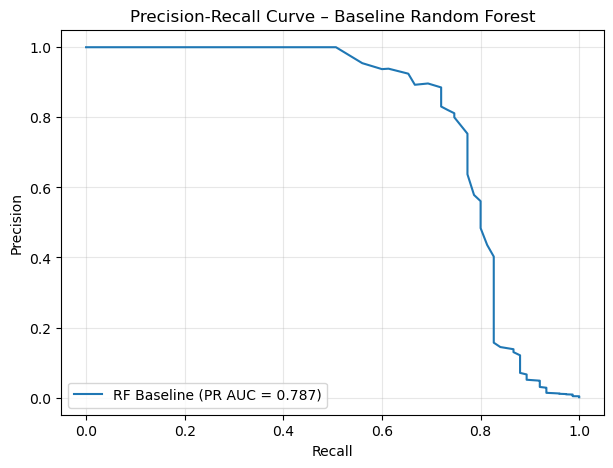

In [187]:
# precision is TP/(TP+FP) 
# recall is TP/(TP+FN). it is the same as sensitivity. it is the ability of the model to identify all the positive samples.

# this code block is plotting the Precision-Recall curve for the baseline Random Forest model and calculating the
#  area under the curve (PR AUC) to evaluate the model's performance in terms of precision and recall trade-off.
precision, recall, _ = precision_recall_curve(y_test, y_scores_rf)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f'RF Baseline (PR AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve – Baseline Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

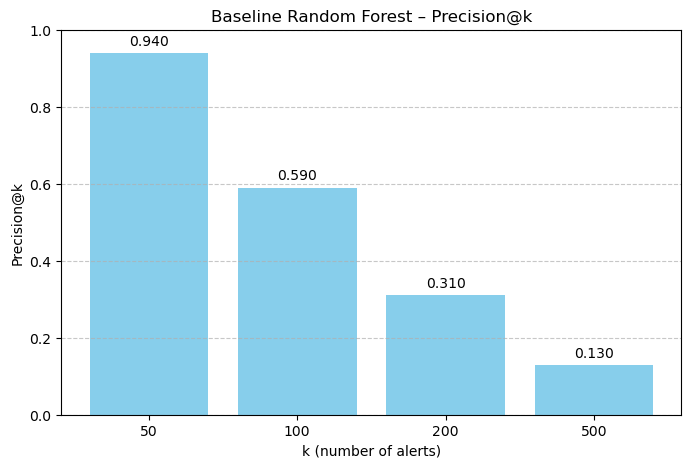

In [188]:
# This code block is creating a bar chart to visualize the Precision@k results for the baseline Random Forest model.
# Precision@k is calculated based on the top k data points ranked by the model's confidence scores (y_scores_rf). 

plt.figure(figsize=(8,5))
plt.bar([str(k) for k in k_values], list(pk_results.values()), color='skyblue')
plt.xlabel('k (number of alerts)')
plt.ylabel('Precision@k')
plt.title('Baseline Random Forest – Precision@k')
plt.ylim(0, 1)
for i, k in enumerate(k_values):
    plt.text(i, pk_results[k] + 0.02, f'{pk_results[k]:.3f}', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Approach 2 -> Captures and Updates on go with the new detected Frauds

In [189]:
df = df.sort_values('Time')

# 1. Calculate the raw integer hour
hour_of_day = (df['Time'] // 3600) % 24

# 2. Add cyclical encoding for the Random Forest to understand the 24-hr loop
df['Hour_Sin'] = np.sin(2 * np.pi * hour_of_day / 24.0)
df['Hour_Cos'] = np.cos(2 * np.pi * hour_of_day / 24.0)

# 3. Define features (make sure to ignore raw Time and Class)
# By saving the raw hour in a variable instead of `df`, we organically keep it out!
feature_cols = [col for col in df.columns if col not in ['Time', 'Class']]
X = df[feature_cols].values
y = df['Class'].values

split_idx = int(0.8 * len(df))
X_train_raw, X_test = X[:split_idx], X[split_idx:]
y_train_raw, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {len(X_train_raw)}, Test size: {len(X_test)}")
print(f"Fraud % in train: {100*np.mean(y_train_raw):.4f}%, test: {100*np.mean(y_test):.4f}%")


Train size: 227845, Test size: 56962
Fraud % in train: 0.1830%, test: 0.1317%


In [190]:
# Cell P2: Parameters for the realistic simulation (adapted for short time span)
delta_batches = 2         # verification latency = 2 batches = 8 hours (since 4h/batch)
k_alerts = 100            # number of alerts (transactions) per batch that investigators check
M_batches = 4             # number of batches of delayed samples to keep in training
Q_batches = M_batches + delta_batches   # number of batches of feedbacks to keep (4+2=6)

In [191]:
# Cell P3: create batch ids and use the first few batches as initial "delayed" data
# Each batch = 4 hours (as used elsewhere), so compute batch index from Time (seconds)
batch_hours = 4
seconds_per_batch = batch_hours * 3600

# ensure Time is numeric and df is sorted chronologically
df = df.sort_values('Time').reset_index(drop=True)

# create batch column (integer)
df['batch'] = (df['Time'] // seconds_per_batch).astype(int)

# list of batch ids (chronological)
batches = sorted(df['batch'].unique())

# Use the first 4 batches as initial delayed data
initial_batches = batches[:4]          # first 4 batches (first 16 hours)
initial_df = df[df['batch'].isin(initial_batches)]
X_init = initial_df[feature_cols].values
y_init = initial_df['Class'].values

# Balance the initial data by undersampling (same helper as baseline)
X_init_bal, y_init_bal = undersample_train(X_init, y_init)

# Train a provisional Random Forest
provisional_rf = RandomForestClassifier(n_estimators=100, random_state=42)
provisional_rf.fit(X_init_bal, y_init_bal)

print("Provisional model trained on initial batches (delayed-only).")

Provisional model trained on initial batches (delayed-only).


In [192]:
# Cell P4: Loop through the next few batches, generate top‑k alerts as feedbacks
feedback_batches = batches[4:8]        # batches 5 to 8 (next 16 hours)
feedbacks_list = []
delayed_list = []

for b in feedback_batches:
    batch_df = df[df['batch'] == b]
    if len(batch_df) == 0:
        continue
    X_batch = batch_df[feature_cols].values
    y_batch = batch_df['Class'].values
    scores = provisional_rf.predict_proba(X_batch)[:, 1]   # fraud probability
    
    n_alerts = min(k_alerts, len(batch_df))
    idx_top = np.argsort(scores)[::-1][:n_alerts]         # indices of top‑k alerts
    feedbacks_list.append(batch_df.iloc[idx_top])         # these become feedbacks
    
    # The rest (non‑alerted) become delayed samples (will be used after latency)
    non_alert_idx = [i for i in range(len(batch_df)) if i not in idx_top]
    delayed_list.append(batch_df.iloc[non_alert_idx])

# Combine all feedbacks from these batches into one DataFrame
F_df = pd.concat(feedbacks_list, ignore_index=True)
# Combine all delayed samples from these batches
D_df = pd.concat(delayed_list, ignore_index=True)

print(f"Feedbacks collected: {len(F_df)} transactions")
print(f"Delayed samples collected: {len(D_df)} transactions")
print(f"Fraud rate in feedbacks: {100*F_df['Class'].mean():.2f}%")
print(f"Fraud rate in delayed: {100*D_df['Class'].mean():.2f}%")

Feedbacks collected: 400 transactions
Delayed samples collected: 83542 transactions
Fraud rate in feedbacks: 34.75%
Fraud rate in delayed: 0.03%


In [193]:
# Train two separate Random Forest models
# Model F: trained only on feedbacks (biased, recent)
X_F = F_df[feature_cols].values
y_F = F_df['Class'].values
X_F_bal, y_F_bal = undersample_train(X_F, y_F)
clf_F = RandomForestClassifier(n_estimators=100, random_state=42)
clf_F.fit(X_F_bal, y_F_bal)

# Model D: trained only on delayed samples (unbiased, older)
X_D = D_df[feature_cols].values
y_D = D_df['Class'].values
X_D_bal, y_D_bal = undersample_train(X_D, y_D)
clf_D = RandomForestClassifier(n_estimators=100, random_state=42)
clf_D.fit(X_D_bal, y_D_bal)

print("Training of F (feedback classifier) and D (delayed classifier) completed.")

Training of F (feedback classifier) and D (delayed classifier) completed.


In [195]:
# Cell P6: Use the remaining batches (after feedback generation) as a test set
test_batches = batches[8:]            # batches 9 to end (last 16 hours)
if len(test_batches) == 0:
    # fallback: use last 20% of rows
    test_df = df.iloc[int(0.8*len(df)):]
else:
    test_df = df[df['batch'].isin(test_batches)]

X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

# Get probabilities from both classifiers
p_F = clf_F.predict_proba(X_test)[:, 1]
p_D = clf_D.predict_proba(X_test)[:, 1]

# Aggregate with equal weight (α = 0.5 as in the paper)
alpha = 0.5
p_agg = alpha * p_F + (1 - alpha) * p_D

# Evaluate the aggregated model
auc_agg = roc_auc_score(y_test, p_agg)
print(f"Proposed Aggregated AUC: {auc_agg:.4f}")

test_amounts = X_test[:, feature_cols.index('Amount')]

k_values = [50, 100, 200]
k_values = [50, 100, 200]
for k in k_values:
    pk = precision_at_k(y_test, p_agg, k)
    rk = recall_at_k(y_test, p_agg, k)
    fk = financial_impact_at_k(y_test, p_agg, test_amounts, k)
    print(f"Precision@{k}: {pk:.4f} | Recall@{k}: {rk:.4f} | Financial Impact@{k}: {fk:.2f}")

Proposed Aggregated AUC: 0.9668
Precision@50: 1.0000 | Recall@50: 0.3676 | Financial Impact@50: -2157.85
Precision@100: 0.9200 | Recall@100: 0.6765 | Financial Impact@100: 2495.33
Precision@200: 0.5150 | Recall@200: 0.7574 | Financial Impact@200: 4408.75


Training Random Forest with Class Weights on entire dataset...
Training completed in 19.92 seconds.
Precision@50: 1.0000 | Recall@50: 0.3676 | Financial Impact@50: -6673.93
Precision@100: 0.9900 | Recall@100: 0.7279 | Financial Impact@100: 8539.57
Precision@200: 0.6050 | Recall@200: 0.8897 | Financial Impact@200: 14668.61
Precision@500: 0.2440 | Recall@500: 0.8971 | Financial Impact@500: 11694.61

=== Weighted Random Forest Results (Full Data) ===
AUC: 0.9622
Precision@50: 1.0000 | Recall@50: 0.3676
Precision@100: 0.9900 | Recall@100: 0.7279
Precision@200: 0.6050 | Recall@200: 0.8897
Precision@500: 0.2440 | Recall@500: 0.8971


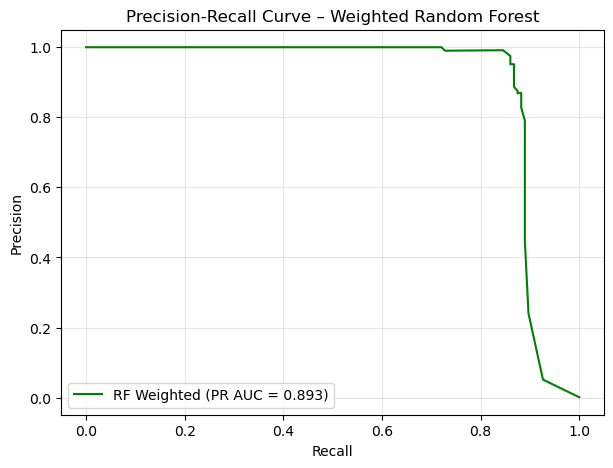

In [197]:
import time

print("Training Random Forest with Class Weights on entire dataset...")
start_time = time.time()

# 1. Train on the FULL raw dataset (no undersampling!)
# Using class_weight='balanced' implicitly forces the trees to mathematically penalize fraud misclassifications
rf_weighted = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
rf_weighted.fit(X_train_raw, y_train_raw)

print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# 2. Evaluate the model on the chronological test set
y_scores_weighted = rf_weighted.predict_proba(X_test)[:, 1]
auc_weighted = roc_auc_score(y_test, y_scores_weighted)

test_amounts = X_test[:, feature_cols.index('Amount')]

k_values = [50, 100, 200, 500]
pk_results_weighted = {}
rk_results_weighted = {}
fk_results_weighted = {}
for k in k_values:
    pk_results_weighted[k] = precision_at_k(y_test, y_scores_weighted, k)
    rk_results_weighted[k] = recall_at_k(y_test, y_scores_weighted, k)
    fk_results_weighted[k] = financial_impact_at_k(y_test, y_scores_weighted, test_amounts, k)

# Update your print statements accordingly:
for k in k_values:
    print(f"Precision@{k}: {pk_results_weighted[k]:.4f} | Recall@{k}: {rk_results_weighted[k]:.4f} | Financial Impact@{k}: {fk_results_weighted[k]:.2f}")

print("\n=== Weighted Random Forest Results (Full Data) ===")
print(f"AUC: {auc_weighted:.4f}")
for k in k_values:
    print(f"Precision@{k}: {pk_results_weighted[k]:.4f} | Recall@{k}: {rk_results_weighted[k]:.4f}")

# 3. Plot the Precision-Recall curve
precision_w, recall_w, _ = precision_recall_curve(y_test, y_scores_weighted)
pr_auc_w = auc(recall_w, precision_w)

plt.figure(figsize=(7,5))
plt.plot(recall_w, precision_w, label=f'RF Weighted (PR AUC = {pr_auc_w:.3f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve – Weighted Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Starting fractional SMOTE + Tomek Links Resampling...
Resampling completed in 37.68 seconds.
New dataset shape: (250156, 33)
Genuine samples: 227421, Fraud samples: 22735

Training Random Forest on fractional SMOTE+Tomek data...
Training completed in 35.13 seconds.

=== Fractional SMOTE + Tomek Links Results ===
AUC: 0.9883
Precision@50: 1.0000 | Recall@50: 0.3676 | Financial Impact@50: -9129.43
Precision@100: 0.9900 | Recall@100: 0.7279 | Financial Impact@100: 5154.35
Precision@200: 0.6050 | Recall@200: 0.8897 | Financial Impact@200: 14668.61
Precision@500: 0.2500 | Recall@500: 0.9191 | Financial Impact@500: 12471.41


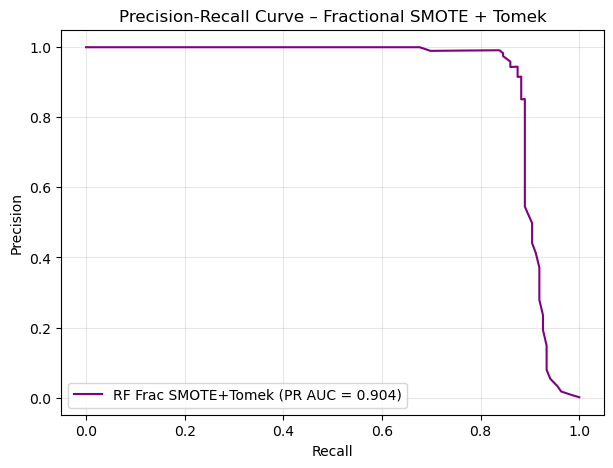

In [200]:
import time
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

print("Starting fractional SMOTE + Tomek Links Resampling...")
start_time = time.time()

# 1. Define the sampling strategy
# 0.1 means the minority class will be 10% the size of the majority class after resampling.
smote_ratio = 0.10 

# 2. Initialize SMOTE with the specific ratio, then pass it to SMOTETomek
smote_custom = SMOTE(sampling_strategy=smote_ratio, random_state=42)
smt = SMOTETomek(smote=smote_custom, random_state=42, n_jobs=-1) 

# Apply the resampling
X_train_smt, y_train_smt = smt.fit_resample(X_train_raw, y_train_raw)

print(f"Resampling completed in {(time.time() - start_time):.2f} seconds.")
print(f"New dataset shape: {X_train_smt.shape}")
print(f"Genuine samples: {(y_train_smt == 0).sum()}, Fraud samples: {(y_train_smt == 1).sum()}")

# 3. Train the Random Forest Model 
print("\nTraining Random Forest on fractional SMOTE+Tomek data...")
train_start = time.time()
rf_smt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smt.fit(X_train_smt, y_train_smt)
print(f"Training completed in {(time.time() - train_start):.2f} seconds.")

# 4. Evaluate the model
y_scores_smt = rf_smt.predict_proba(X_test)[:, 1]
auc_smt = roc_auc_score(y_test, y_scores_smt)

test_amounts = X_test[:, feature_cols.index('Amount')]

k_values = [50, 100, 200, 500]
pk_results_smt = {}
rk_results_smt = {}
fk_results_smt = {}
for k in k_values:
    pk_results_smt[k] = precision_at_k(y_test, y_scores_smt, k)
    rk_results_smt[k] = recall_at_k(y_test, y_scores_smt, k)
    fk_results_smt[k] = financial_impact_at_k(y_test, y_scores_smt, test_amounts, k)

print("\n=== Fractional SMOTE + Tomek Links Results ===")
print(f"AUC: {auc_smt:.4f}")
for k in k_values:
    print(f"Precision@{k}: {pk_results_smt[k]:.4f} | Recall@{k}: {rk_results_smt[k]:.4f} | Financial Impact@{k}: {fk_results_smt[k]:.2f}")

# 5. Plot the Precision-Recall curve
precision_smt, recall_smt, _ = precision_recall_curve(y_test, y_scores_smt)
pr_auc_smt = auc(recall_smt, precision_smt)

plt.figure(figsize=(7,5))
plt.plot(recall_smt, precision_smt, label=f'RF Frac SMOTE+Tomek (PR AUC = {pr_auc_smt:.3f})', color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – Fractional SMOTE + Tomek')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Starting XGBoost Training on the entire dataset...
Calculated scale_pos_weight: 545.39 (Fraud errors penalized 545x more)
Training completed in 1.06 seconds.

=== XGBoost Results (Full Data + Scale Pos Weight) ===
AUC: 0.9925
Precision@50: 1.0000 | Recall@50: 0.3676 | Financial Impact@50: -5324.25
Precision@100: 0.9600 | Recall@100: 0.7059 | Financial Impact@100: 3487.79
Precision@200: 0.6000 | Recall@200: 0.8824 | Financial Impact@200: 14184.09
Precision@500: 0.2460 | Recall@500: 0.9044 | Financial Impact@500: 11709.01


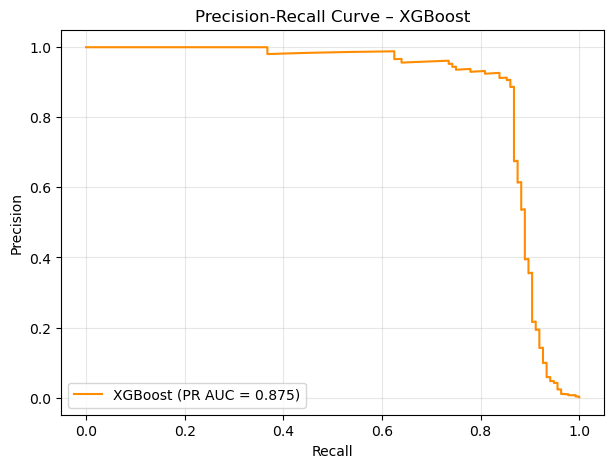

In [201]:

import time
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

print("Starting XGBoost Training on the entire dataset...")
start_time = time.time()

# 1. Calculate the exact ratio of Negative to Positive cases
neg_class_count = (y_train_raw == 0).sum()
pos_class_count = (y_train_raw == 1).sum()
scale_pos_weight_value = neg_class_count / pos_class_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f} (Fraud errors penalized {int(scale_pos_weight_value)}x more)")

# 2. Initialize and Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,                 # Standard depth for heavily imbalanced trees
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_value,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_raw, y_train_raw)

print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# 3. Evaluate the model on the chronological test set
y_scores_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_scores_xgb)

test_amounts = X_test[:, feature_cols.index('Amount')]

k_values = [50, 100, 200, 500]
pk_results_xgb = {}
rk_results_xgb = {}
fk_results_xgb = {}
for k in k_values:
    pk_results_xgb[k] = precision_at_k(y_test, y_scores_xgb, k)
    rk_results_xgb[k] = recall_at_k(y_test, y_scores_xgb, k)
    fk_results_xgb[k] = financial_impact_at_k(y_test, y_scores_xgb, test_amounts, k)

print("\n=== XGBoost Results (Full Data + Scale Pos Weight) ===")
print(f"AUC: {auc_xgb:.4f}")
for k in k_values:
    print(f"Precision@{k}: {pk_results_xgb[k]:.4f} | Recall@{k}: {rk_results_xgb[k]:.4f} | Financial Impact@{k}: {fk_results_xgb[k]:.2f}")

# 4. Plot the Precision-Recall curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_scores_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR AUC = {pr_auc_xgb:.3f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve – XGBoost')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
